<a href="https://colab.research.google.com/github/ketannehra9/Data-Science-Guided-Projects/blob/main/GP_4_Medi_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK #1: UNDERSTAND THE PROBLEM STATEMENT**

In [ ]:
!pip install jupyterthemes

**TASK #2: IMPORT LIBRARIES AND DATASETS**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from jupyterthemes import jtplot
jtplot.style(theme = 'monokai',
             context = 'notebook',
             ticks = True,
             grid = False)


# read the dataset
insurance_df = pd.read_csv('insurance.csv')

insurance_df

insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**TASK #3: PERFORM EXPLORATORY DATA ANALYSIS - PART 1**

,bmi,children,charges
age,,,
18,31.326159,0.449275,7086.217556
19,28.596912,0.426471,9747.909335
20,30.632759,0.862069,10159.697736
21,28.185714,0.785714,4730.464330
22,31.087679,0.714286,10012.932802
23,31.454464,1.000000,12419.820040
24,29.142679,0.464286,10648.015962
25,29.693929,1.285714,9838.365311
26,29.428929,1.071429,6133.825309


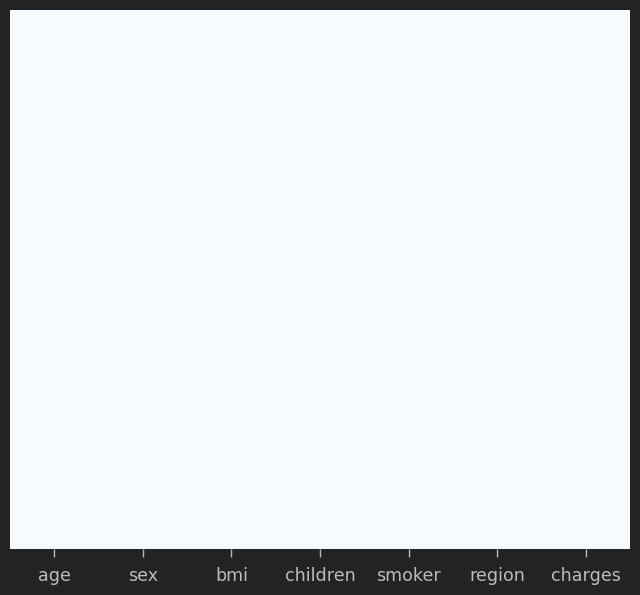

In [ ]:
insurance_df.isnull()
insurance_df.isnull().sum()

sns.heatmap(insurance_df.isnull(), yticklabels = False, cbar = False, cmap = 'Blues')
# blank means no nulls

insurance_df.describe()

df_regions = insurance_df.groupby(by = 'region').mean(numeric_only=True)
(df_regions)


# PRACTICE-OPPORTUNITY-1
df_age = insurance_df.groupby(by = 'age').mean(numeric_only = True)
df_age

**TASK #4: PERFORM FEATURE ENGINEERING**

In [ ]:
insurance_df['sex'] = insurance_df['sex'].apply(lambda x: 0 if x == 'female' else 1)
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,no,northwest,10600.54830
1334,18,0,31.920,0,no,northeast,2205.98080
1335,18,0,36.850,0,no,southeast,1629.83350
1336,21,0,25.800,0,no,southwest,2007.94500


In [ ]:
insurance_df['smoker'] = insurance_df['smoker'].apply(lambda x: 0 if x == 'no' else 1)
insurance_df



,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [ ]:
region_dummies = pd.get_dummies(insurance_df['region'], drop_first = True, dtype=int)
region_dummies

insurance_df = pd.concat([insurance_df, region_dummies], axis = 1)
insurance_df

,age,sex,bmi,children,smoker,region,charges,northwest,southeast,southwest
0,19,0,27.900,0,1,southwest,16884.92400,0,0,1
1,18,1,33.770,1,0,southeast,1725.55230,0,1,0
2,28,1,33.000,3,0,southeast,4449.46200,0,1,0
3,33,1,22.705,0,0,northwest,21984.47061,1,0,0
4,32,1,28.880,0,0,northwest,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830,1,0,0
1334,18,0,31.920,0,0,northeast,2205.98080,0,0,0
1335,18,0,36.850,0,0,southeast,1629.83350,0,1,0
1336,21,0,25.800,0,0,southwest,2007.94500,0,0,1


In [ ]:
insurance_df.drop(['region'], axis = 1, inplace = True)


In [ ]:
insurance_df

,age,sex,bmi,children,smoker,charges,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


**TASK 5: DATA VISUALIZATION**

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>],
       [<Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'children'}>],
       [<Axes: title={'center': 'smoker'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

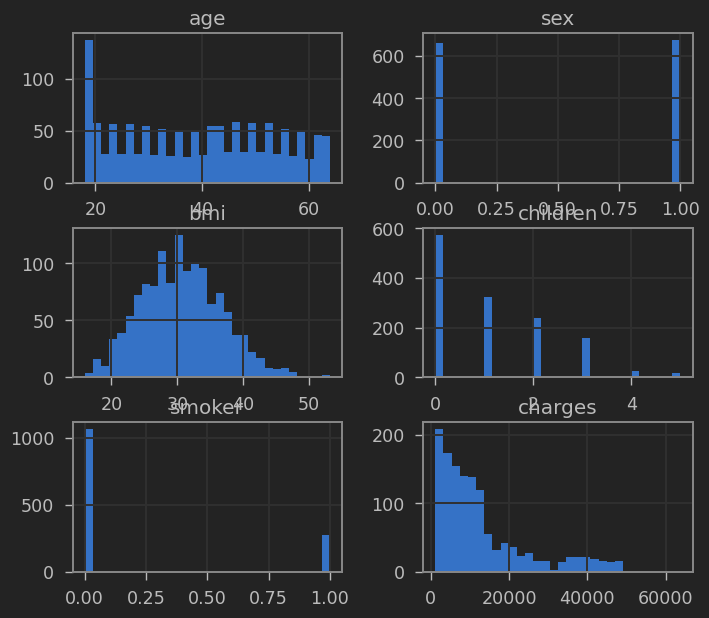

In [ ]:
insurance_df[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].hist(bins = 30)

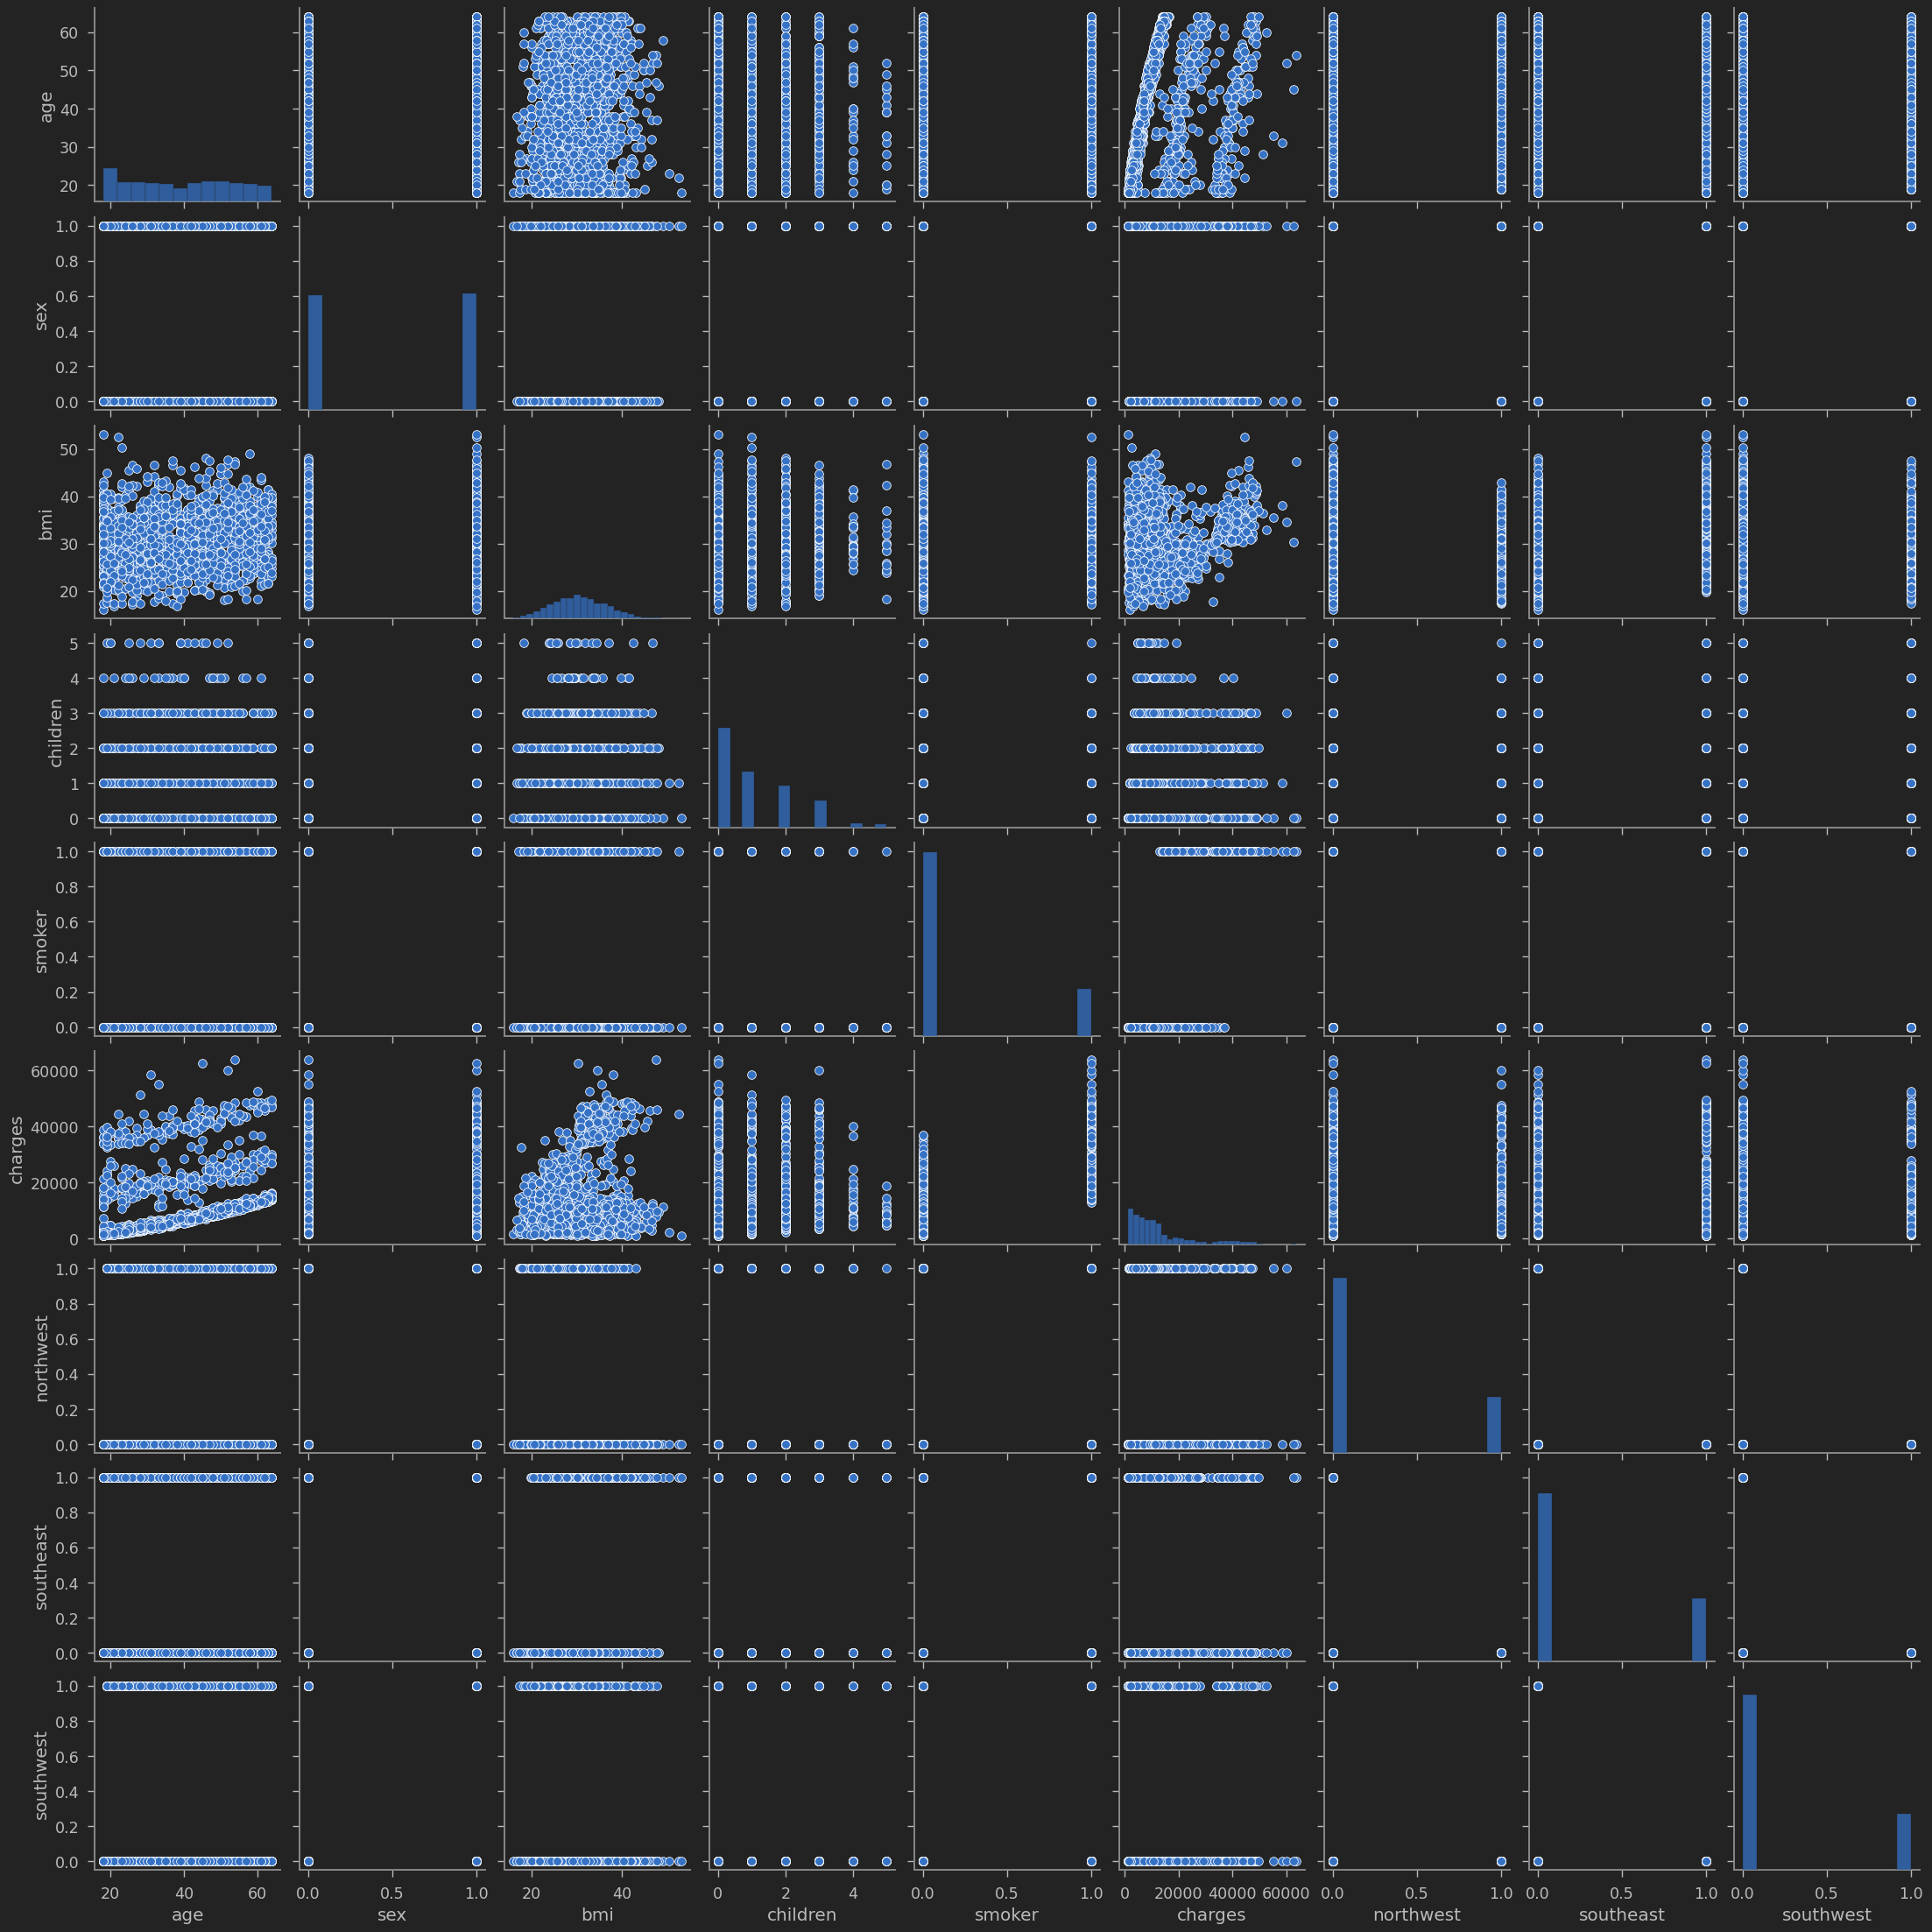

In [ ]:
sns.pairplot(insurance_df)

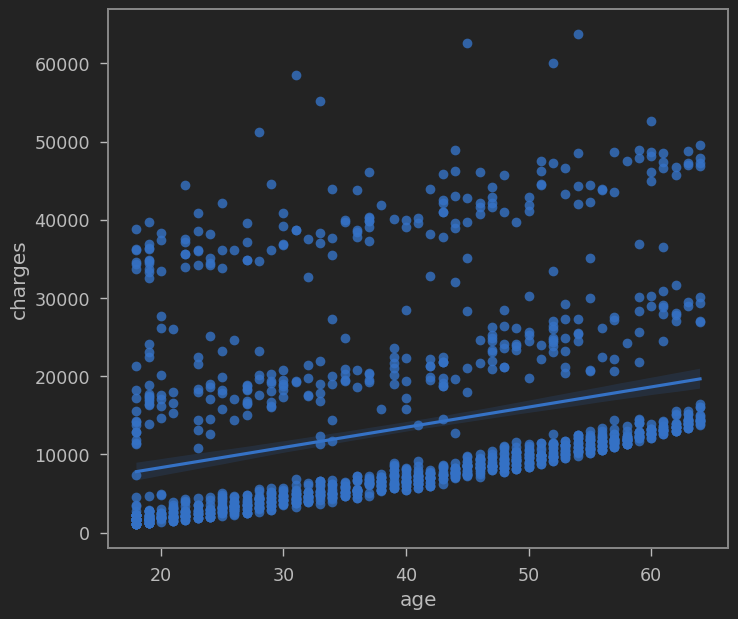

In [ ]:
sns.regplot(x = 'age', y = 'charges', data = insurance_df)
plt.show()

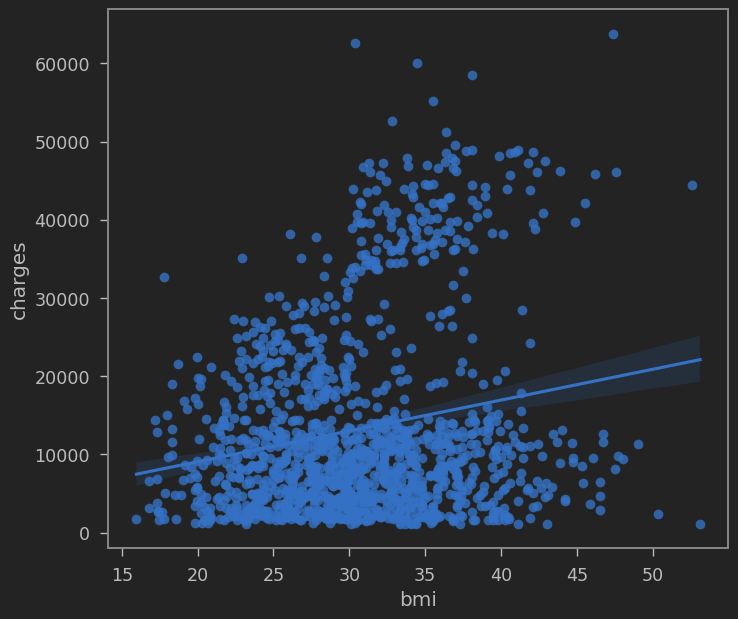

In [ ]:
sns.regplot(x = 'bmi', y = 'charges', data = insurance_df)
plt.show()

In [ ]:
# PRACTICE - OPPORTUNITY - 2

insurance_df.corr()

,age,sex,bmi,children,smoker,charges,northwest,southeast,southwest
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008,-0.000407,-0.011642,0.010016
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292,-0.011156,0.017117,-0.004184
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341,-0.135996,0.270025,-0.006205
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998,0.024806,-0.023066,0.021914
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251,-0.036945,0.068498,-0.036945
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000,-0.039905,0.073982,-0.043210
northwest,-0.000407,-0.011156,-0.135996,0.024806,-0.036945,-0.039905,1.000000,-0.346265,-0.320829
southeast,-0.011642,0.017117,0.270025,-0.023066,0.068498,0.073982,-0.346265,1.000000,-0.346265
southwest,0.010016,-0.004184,-0.006205,0.021914,-0.036945,-0.043210,-0.320829,-0.346265,1.000000


<Axes: >

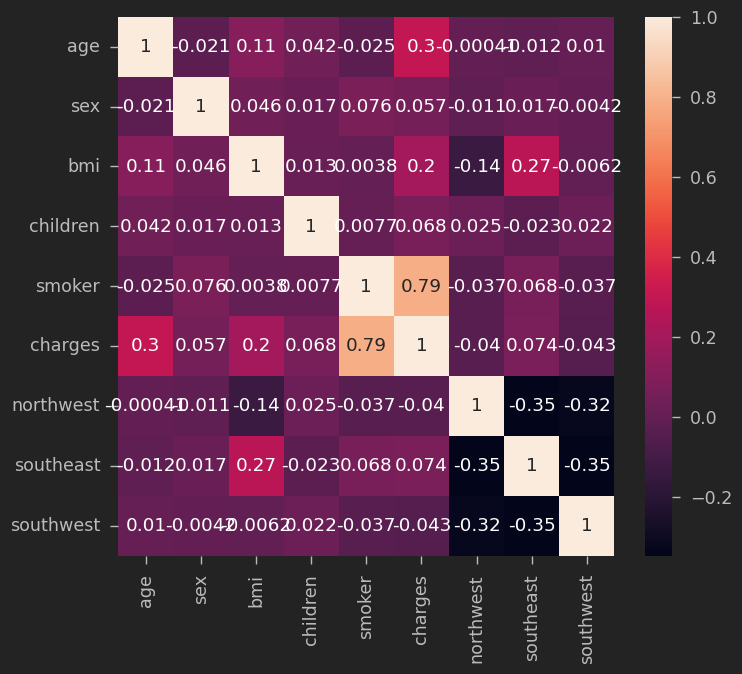

In [ ]:
sns.heatmap(insurance_df.corr(), annot = True)

**TASK #6: CREATE TRAINING AND TESTING DATASET**

In [ ]:
X = insurance_df.drop(columns = ['charges'])
y = insurance_df['charges']

In [ ]:
X = np.array(X).astype('float32')
y = np.array(y).astype('float32')

In [ ]:
y = y.reshape(-1, 1)
y.shape

(1338, 1)

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
X = scaler_x.fit_transform(X)


In [ ]:

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y)

In [ ]:
# PRACTICE - OPPORTUNITY - 3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =42)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1070, 8)
(268, 8)


**TASK #7: TRAIN AND EVALUATE A LINEAR REGRESSION MODEL IN SCIKIT-LEARN**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
model_accuracy = model.score(X_test, y_test)
model_accuracy

0.7835929989814758

In [ ]:
y_predict = model.predict(X_test)
y_predict_orig = scaler_y.inverse_transform(y_predict)
y_test_orig = scaler_y.inverse_transform(y_test)


In [ ]:
k = X_test.shape[1]
n = len(X_test)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt

RMSE = float(format(np.sqrt(mean_squared_error(y_test_orig, y_predict_orig))))
MSE = mean_squared_error(y_test_orig, y_predict_orig)
MAE = mean_absolute_error(y_test_orig, y_predict_orig)
r2 = r2_score(y_test_orig, y_predict_orig)
adj_r2 = 1 - (1 - r2) * (n - 1)/ (n - k - 1)

print(RMSE)
print(MSE)
print(MAE)
print(r2)
print(adj_r2)


5796.284327049528
33596912.0
4181.1943359375
0.7835929989814758
0.7769086128496295


**TASK #8: TRAIN AND EVALUATE AN ARTIFICIAL NEURAL NETWORK-BASED REGRESSION MODEL**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [ ]:
ANN_model = keras.Sequential()
ANN_model.add(Dense(50, input_dim = 8))
ANN_model.add(Activation('relu'))
ANN_model.add(Dense(150))
ANN_model.add(Activation('relu'))
ANN_model.add(Dense(150))
ANN_model.add(Activation('relu'))
ANN_model.add(Dense(50))
ANN_model.add(Activation('linear'))
ANN_model.add(Dense(1))
ANN_model.compile(loss = 'mse', optimizer = 'adam')
ANN_model.summary()




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 150)            │         7,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,351 (149.81 KB)

 Trainable params: 38,351 (149.81 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ANN_model.compile(optimizer = 'adam', loss = 'mean_squared_error')
epochs_hist = ANN_model.fit(X_train, y_train, epochs = 100, batch_size = 20, validation_split = 0.2)


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.6367 - val_loss: 0.3032
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2163 - val_loss: 0.1878
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1817 - val_loss: 0.1825
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1594 - val_loss: 0.1795
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1447 - val_loss: 0.1682
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1339 - val_loss: 0.1557
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1343 - val_loss: 0.1520
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1298 - val_loss: 0.1627
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1106 - val_loss: 0.1455
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1400 - val_loss: 0.1585
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1318 - val_loss: 0.1442
Epoch 12/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step -

In [ ]:
result = ANN_model.evaluate(X_test, y_test)
accuracy_ANN = 1 - result

print(f'Accuracy: {accuracy_ANN}')

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1883 
Accuracy: 0.7860436737537384


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


Text(0, 0.5, 'Actual')

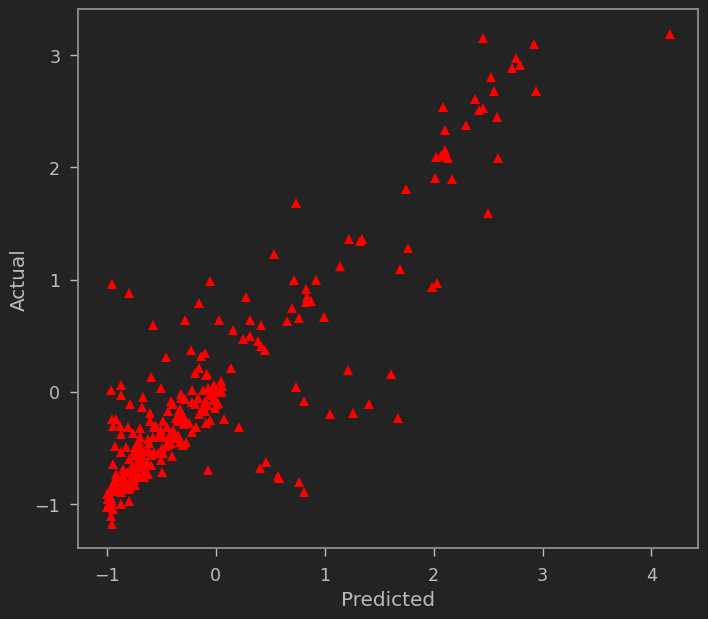

In [ ]:
y_predict = ANN_model.predict(X_test)
plt.plot(y_test, y_predict,"^", color = 'red')
plt.xlabel('Predicted')
plt.ylabel('Actual')